In [153]:
import xarray as xr
import numpy as np
import pandas as pd
#import xesmf as xe



In [ ]:
#Hindcast Data: https://cds.climate.copernicus.eu/datasets/seasonal-monthly-single-levels?tab=download
#Note fixed hindcast period here: https://confluence.ecmwf.int/display/CKB/Description+of+the+C3S+seasonal+multi-system
#ERA5 Monthly Average (1981-2016): https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-monthly-means?tab=download

In [ ]:
def adjust_month_leadtime(ds, lead):
    ds = ds.copy()
    ref = ds.month.values   
    lead = lead-1            

    actual = np.array([
        (((ref_t - lead-1)%12) +1)
        for ref_t in ref
    ])

    ds = ds.assign_coords(
        month=(["month"], actual)
    )
    return ds

def subtract_clim(group):
    fm = int(group.forecastMonth.values[0])
    clim_adjusted = adjust_month_leadtime(climatology, fm)
    return group - clim_adjusted


In [154]:
ds_hindcast = xr.open_dataset('./data/s51_hcm_allmonths.nc')
da_hindcast = ds_hindcast['t2m'].assign_coords(forecast_reference_time=ds_hindcast.forecast_reference_time.dt.month).rename({'forecast_reference_time':'month'})

ds_era5_hcperiod = xr.open_dataset("./data/era5_monthly_1981_2016.nc")
da_era5 = ds_era5_hcperiod['t2m'].sel(valid_time = slice("1993-01-01", "2016-12-01")).groupby("valid_time.month").mean()

#regridder = xe.Regridder(da_era5, da_hindcast, "bilinear")
#da_era5_regridded = regridder(da_era5)
da_era5_regridded = da_era5.interp_like(da_hindcast, method="linear")


In [200]:
climatology = da_era5_regridded
bias_adj = da_hindcast.groupby("forecastMonth").map(subtract_clim)

In [202]:
bias_adj.to_zarr("bias_adjustment_ERA5_19932016.zarr", zarr_format=2)

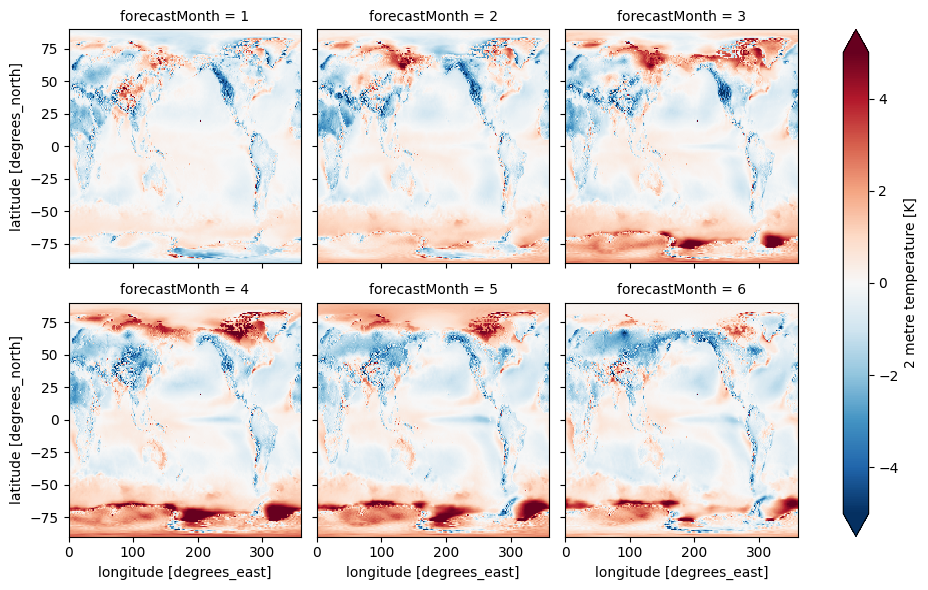

In [203]:
bias_adj.sel(month = 1).plot(col="forecastMonth", col_wrap=3, vmin = -5, vmax = 5, cmap = 'RdBu_r')